# DP2 starter notebook

Make sure you choose the **latest Weekly release** when you run this notebook on the RSP. This will give you the latest software versions with bug fixes and performance improvements.

## Setup

In [1]:
import lsdb

import astropy.units as u
from astropy.coordinates import SkyCoord
from upath import UPath
import matplotlib.pyplot as plt

In [2]:
# Setup
from dask.distributed import Client
client = Client(n_workers=4, memory_limit="4GiB", threads_per_worker=1)
print(f"Dask is running at: {client.dashboard_link}")

/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36811 instead
  warnings.warn(


Dask is running at: http://127.0.0.1:36811/status


## Open catalog

/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


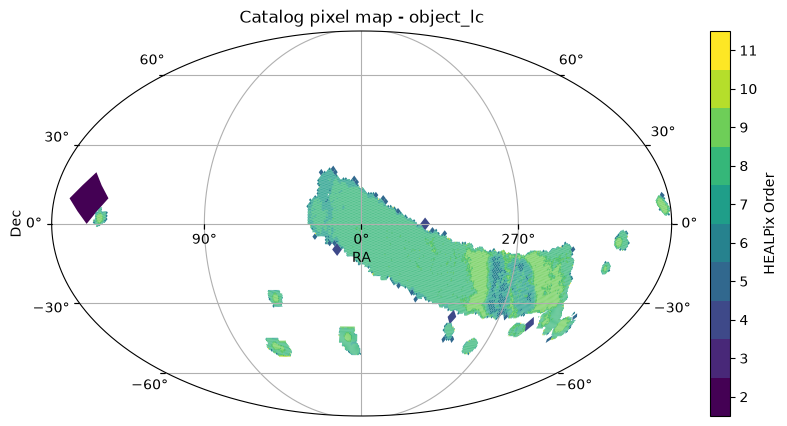

In [23]:
# Open DP2 catalog and plot
base_path = UPath("/astro/store/shire/hats/dash/hats/v30_0_6/")

cat = lsdb.open_catalog(base_path / "object_collection")
cat.plot_pixels();

In [24]:
base_path = UPath("/astro/store/shire/hats/dash/hats/v30_0_6/")

# Choose catalog
# Object catalog: "object_collection"
# DiaObject catalog: "dia_object_collection"
cat = lsdb.open_catalog(base_path / "object_collection",
# Select columns
# TODO update column description link
# Column descriptions available at https://sdm-schemas.lsst.io/dp1.html
    columns=['g_psfFlux', 'g_psfMag', 'r_psfFlux']
# Select a sky region
    ).cone_search(ra=270.0, dec=-30.0, radius_arcsec=2*3600
# Query on column values
    ).query('g_psfFlux > 2.0 and r_psfFlux > 7.0')


In [25]:
# Check catalog
cat

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec
npartitions=74,,,,,
"Order: 7, Pixel: 114910",float[pyarrow],float[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 7, Pixel: 114911",...,...,...,...,...
...,...,...,...,...,...
"Order: 7, Pixel: 115488",...,...,...,...,...
"Order: 7, Pixel: 115489",...,...,...,...,...


## Plot catalog

/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


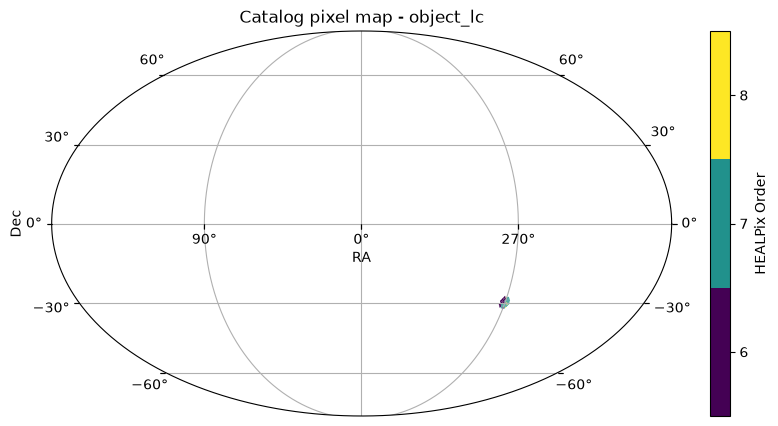

In [26]:
# Plot catalog
cat.plot_pixels();

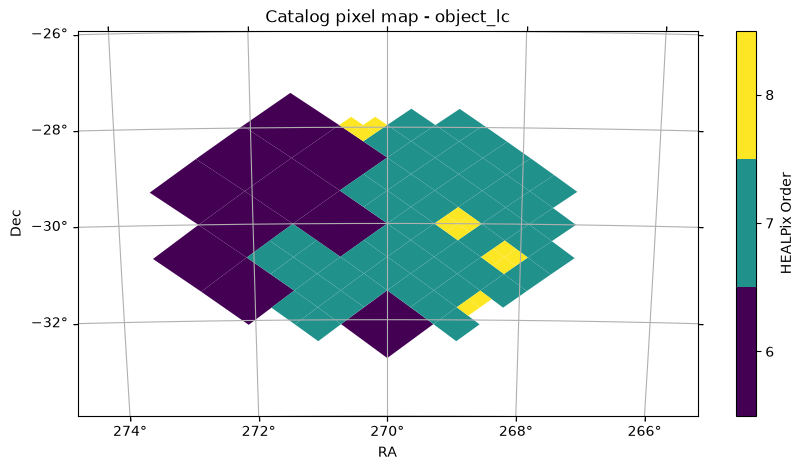

In [27]:
# Plot zoomed catalog
import astropy.units as u
fov = (8 * u.deg, 8 * u.deg)
center = SkyCoord(270 * u.deg, -30 * u.deg)
fig, ax = cat.plot_pixels(projection="AIT", fov=fov, center=center);

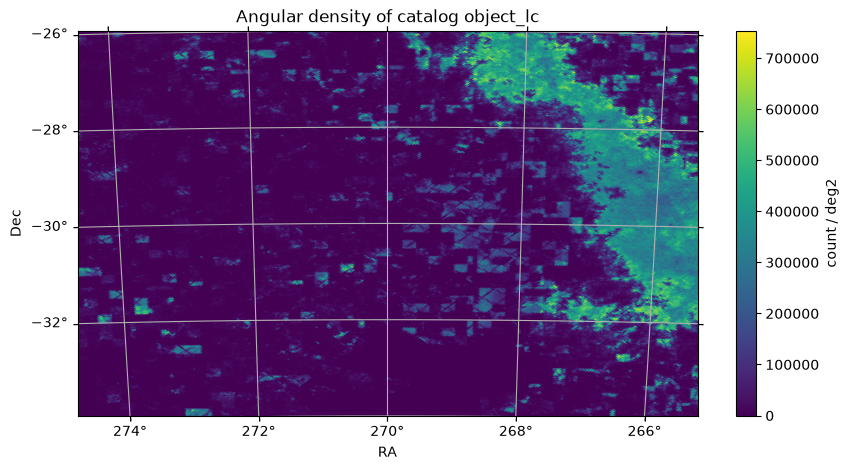

In [28]:
# Plot density
import hats
hats.inspection.plot_density(cat.hc_structure, ec='face', projection="AIT", fov=fov, center=center);

## Map a function

In [9]:
# Map a function

# The mappable function takes in a dataframe that represents a partition.
# It returns a dataframe.
def g_minus_r_mapper(df):
    import numpy as np
    df['g_minus_r_mag'] = -np.log(df['g_psfFlux'] / df['r_psfFlux'])
    return df

cat = cat.map_partitions(g_minus_r_mapper)


## Compute catalog

In [11]:
# Check catalog before computing
cat.head()

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec,g_minus_r_mag
_healpix_29,,,,,,
2021882992298765515,6312.816406,21.899443,950.743286,269.492478,-31.944853,-1.893093
2021885912268212287,722.161804,24.253414,9836.803711,269.525976,-31.936126,2.611637
2021885913480368752,1189.062744,23.711988,13368.254883,269.518602,-31.936637,2.419718
2021886052086887385,22559.029297,20.516699,95027.460938,269.499125,-31.911018,1.438030
2021886089486228703,684.218628,24.312014,15117.708984,269.493208,-31.897396,3.095345


In [12]:
# Compute catalog and write to disk
cat.write_catalog('dp2_example_cat', overwrite=True)

In [13]:
# Compute catalog to dataframe
df = cat.compute()

In [14]:
# Read catalog from disk
cat = lsdb.open_catalog('dp2_example_cat')

## Crossmatch

In [15]:
# Crossmatch
gaia_cat = lsdb.open_catalog('https://data.lsdb.io/hats/gaia_dr3',
                            columns=['pmra', 'pmdec', 'parallax', 'phot_g_mean_mag'])
gaia_cat

,pmra,pmdec,parallax,phot_g_mean_mag,ra,dec
npartitions=2016,,,,,,
"Order: 2, Pixel: 0",double[pyarrow],double[pyarrow],double[pyarrow],float[pyarrow],double[pyarrow],double[pyarrow]
"Order: 2, Pixel: 1",...,...,...,...,...,...
...,...,...,...,...,...,...
"Order: 3, Pixel: 766",...,...,...,...,...,...
"Order: 3, Pixel: 767",...,...,...,...,...,...


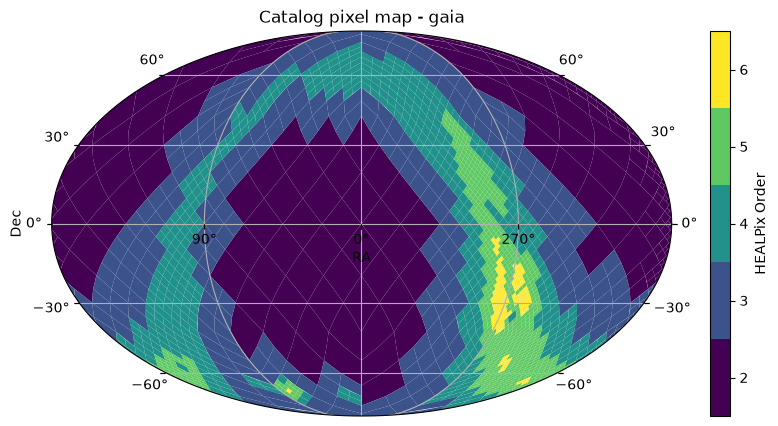

In [16]:
gaia_cat.plot_pixels();

In [17]:
# Crossmatch LSST catalog with Gaia catalog
x_cat = cat.crossmatch(gaia_cat, suffix_method='overlapping_columns'
# Filter out extraneous matches: match rows should have similar magnitude
                      ).query('-1.0 < g_psfMag - phot_g_mean_mag < 1.0')

In [18]:
x_cat.head()

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec,g_minus_r_mag,pmra,pmdec,parallax,phot_g_mean_mag,ra,dec,_dist_arcsec
_healpix_29,,,,,,,,,,,,,
2021964496015623238,9673.453125,21.436047,42565.773438,270.967326,-30.960966,1.481665,<NA>,<NA>,<NA>,20.714178,270.967418,-30.960977,0.288048
2022006544697997495,120459.726562,18.697895,290390.96875,269.657039,-31.313142,0.879913,-1.077293,-1.839642,0.458377,17.735134,269.657049,-31.313134,0.041237
2022006726568729025,8043.849121,21.636341,37208.722656,269.679652,-31.294696,1.531636,<NA>,<NA>,<NA>,20.707853,269.679646,-31.29465,0.166786
2022006804832192246,6872.813477,21.807163,37648.890625,269.689101,-31.275892,1.70073,<NA>,<NA>,<NA>,21.011015,269.689088,-31.275955,0.228752
2022006908920589465,696306.875,16.792997,1653694.375,269.62221,-31.314808,0.864977,-1.84308,-12.179346,0.620065,15.840422,269.622216,-31.314774,0.121875


/astro/users/smcampos/.conda/envs/lsdb/lib/python3.13/site-packages/hats/inspection/_plotting.py:153: UserWarning: This plot contains HEALPix pixels smaller than a pixel of the plot. Some values may be lost
  warnings.warn(


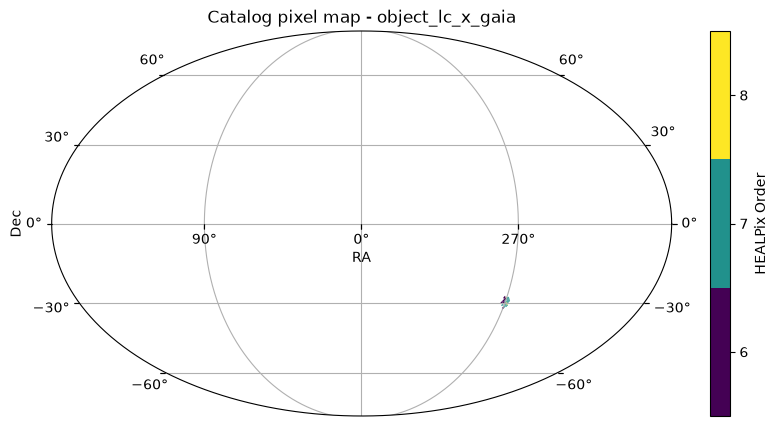

In [19]:
x_cat.plot_pixels();

In [20]:
x_df = x_cat.compute()

In [21]:
x_df

,g_psfFlux,g_psfMag,r_psfFlux,coord_ra,coord_dec,g_minus_r_mag,pmra,pmdec,parallax,phot_g_mean_mag,ra,dec,_dist_arcsec
_healpix_29,,,,,,,,,,,,,
2021964496015623238,9673.453125,21.436047,42565.773438,270.967326,-30.960966,1.481665,<NA>,<NA>,<NA>,20.714178,270.967418,-30.960977,0.288048
2022006544697997495,120459.726562,18.697895,290390.96875,269.657039,-31.313142,0.879913,-1.077293,-1.839642,0.458377,17.735134,269.657049,-31.313134,0.041237
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031704193132014162,288749.28125,17.748697,731717.125,268.945454,-28.23833,0.929835,-0.645325,-1.935509,0.923073,16.882021,268.945458,-28.238325,0.021069
2031705077646264136,11016.887695,21.294853,51618.363281,269.033732,-28.198182,1.544448,<NA>,<NA>,<NA>,20.31847,269.033819,-28.198221,0.309489


<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
/local/tmp/ipykernel_132794/753833943.py:3: SyntaxWarning: invalid escape sequence '\p'
  plt.ylabel('$\pi$ (Gaia)');


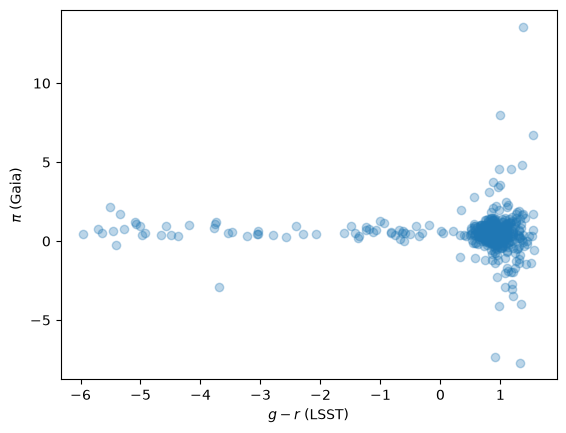

In [22]:
plt.scatter(x_df['g_minus_r_mag'], x_df['parallax'], alpha=0.3);
plt.xlabel('$g-r$ (LSST)');
plt.ylabel('$\pi$ (Gaia)');

In [ ]:
## Close Dask client

In [ ]:
# Clean up
client.close()